# Basics Of PCA
#### (And Why You Shouldn't Use Unsupervised Techniques With Supervised Problems)

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy
import statsmodels.api as sm

matplotlib.rcParams['figure.figsize'] = (20, 10)

In [ ]:
def generate_classifier_data(rnge, k, d, sizes, seed):


    rng = numpy.random.default_rng(seed=seed)
    cs = [numpy.array([0,2]), numpy.array([0, -2])]
    sigma = numpy.array([[20,-5], [-5,1]])
    classes = [rng.multivariate_normal(c, sigma, size=size) for c, size in zip(cs,sizes)]
    ys = [j*numpy.ones(shape=(size, 1)) for j, size in enumerate(sizes)]
    xs = numpy.vstack(classes)
    ys = numpy.vstack(ys)
    return (xs, ys)


In [ ]:
rnge = [-20,20]
k = 2
d = 2
sizes = [500, 500]
X, y = generate_classifier_data(rnge, k, d, sizes, 8675309)

<ipython-input-59-0d869f00e312>:7: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  classes = [rng.multivariate_normal(c, sigma, size=size) for c, size in zip(cs,sizes)]


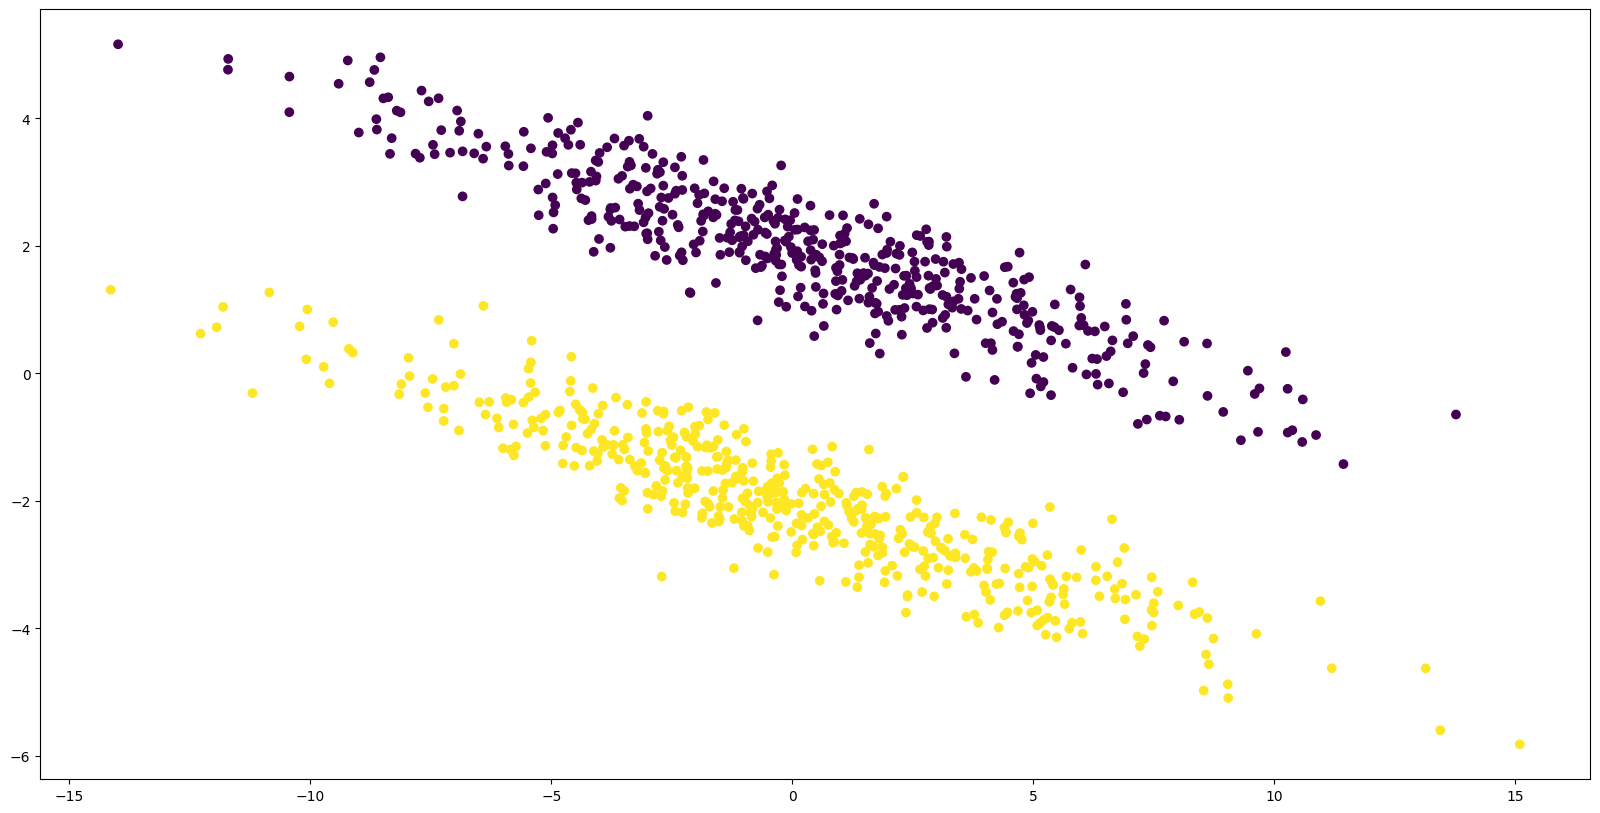

In [ ]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [ ]:
class PCA():
  def __init__(self):
    pass

  def fit(self, X):
    X_centered = X - X.mean(axis=0)
    self.U, self.s, self.Vt = numpy.linalg.svd(X_centered)
    self.explained_variance_ratio = self.s/numpy.sum(self.s)

  def predict(self,k):
    return (numpy.matmul(self.U[:,:k], numpy.diag(self.s[:k])), self.Vt[:k, :])


In [ ]:
pca = PCA()
pca.fit(X)
X_1, v_1 = pca.predict(1)

In [ ]:
(pca.U, pca.s, pca.Vt)

(array([[ 3.88755965e-03, -3.62344473e-02, -1.27984994e-02, ...,
          1.34008818e-02, -2.38031840e-02,  4.08723888e-02],
        [ 4.81823730e-03, -3.50806348e-02, -4.68233196e-02, ...,
          2.78366787e-02,  2.69090495e-02,  1.46751194e-02],
        [-5.06947600e-03, -4.82624124e-02,  9.97739772e-01, ...,
          1.40825501e-03,  9.51753075e-04,  1.11911705e-03],
        ...,
        [ 8.73238948e-03,  2.96362242e-02,  1.41788067e-03, ...,
          9.99085171e-01, -4.28104062e-04, -9.01910630e-04],
        [-2.78493308e-02,  2.26578952e-02,  8.99972353e-04, ...,
         -3.91788386e-04,  9.98712189e-01,  6.29577232e-04],
        [ 3.79819097e-02,  2.11337777e-02,  1.18037492e-03, ...,
         -9.35311894e-04,  5.78143900e-04,  9.98143586e-01]]),
 array([142.80662716,  62.94524913]),
 array([[-0.96058692,  0.27797981],
        [-0.27797981, -0.96058692]]))

In [ ]:
proj = numpy.matmul(X_1, v_1)

In [ ]:
proj

array([[-0.53328835,  0.15432585],
       [-0.66095701,  0.19127129],
       [ 0.69542148, -0.20124481],
       ...,
       [-1.19789328,  0.3466528 ],
       [ 3.82032045, -1.10554487],
       [-5.21028917,  1.50778149]])

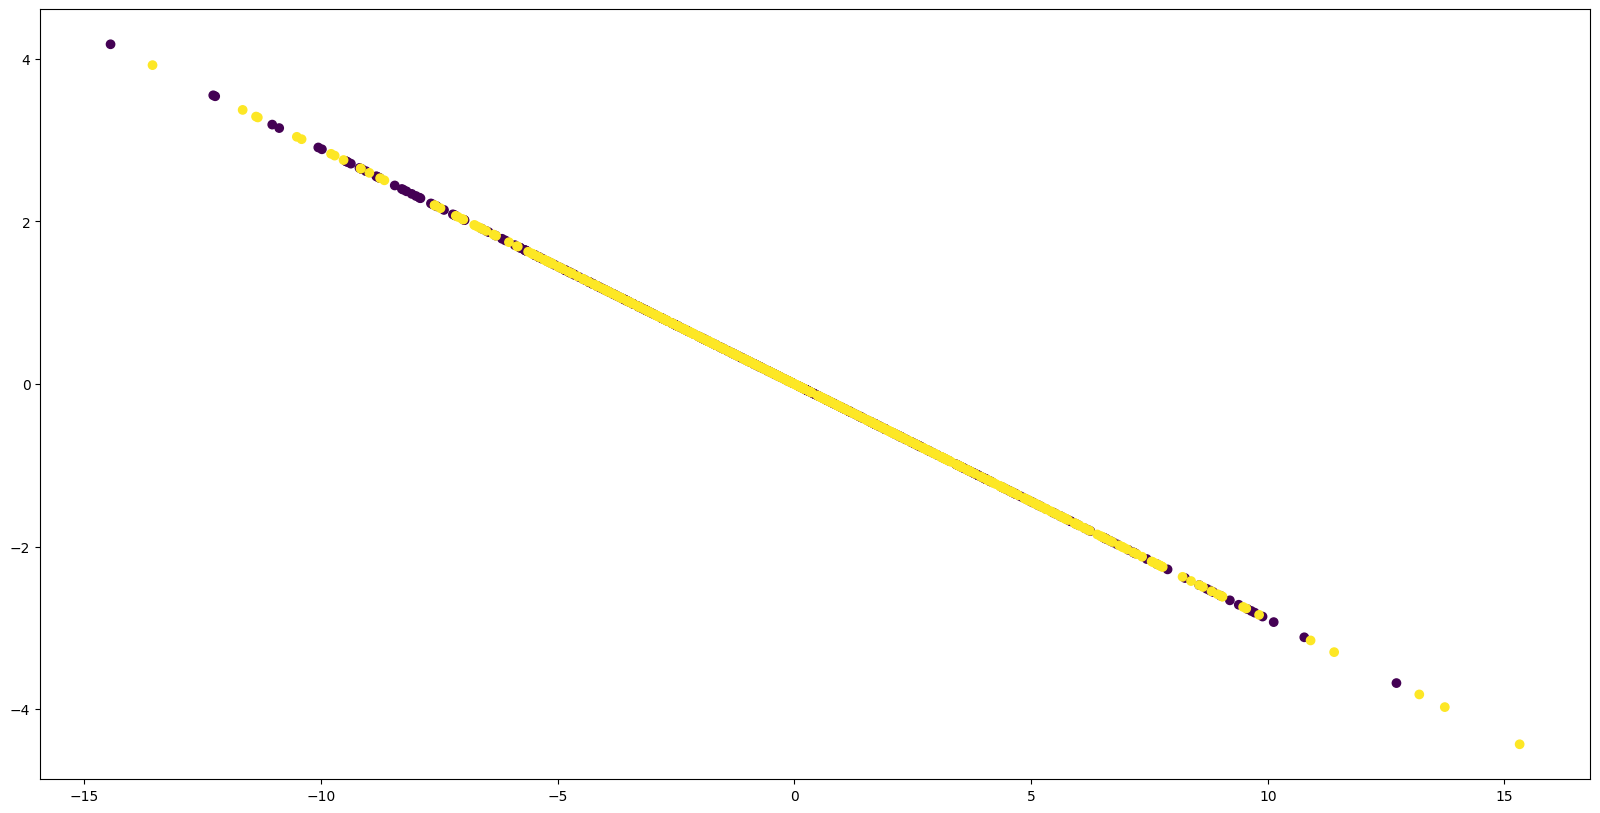

In [ ]:
plt.scatter(proj[:,0], proj[:,1], c=y)
plt.show()

# How To Choose Number of Components

In [ ]:
def generate_data( k, d, r, seed):


    rng = numpy.random.default_rng(seed=seed)
    cov = numpy.array([[5, -1], [-1, 5]])
    U = rng.multivariate_normal([0,0], cov, k)
    V = rng.integers(-10, 10, (r, d))
    structure = numpy.matmul(U, V)
    noise = rng.normal(0, 0.1, (k,d))
    return structure + noise

In [ ]:
data = generate_data(10000, 20, 2, 8675309)

In [ ]:
data.shape

(10000, 20)

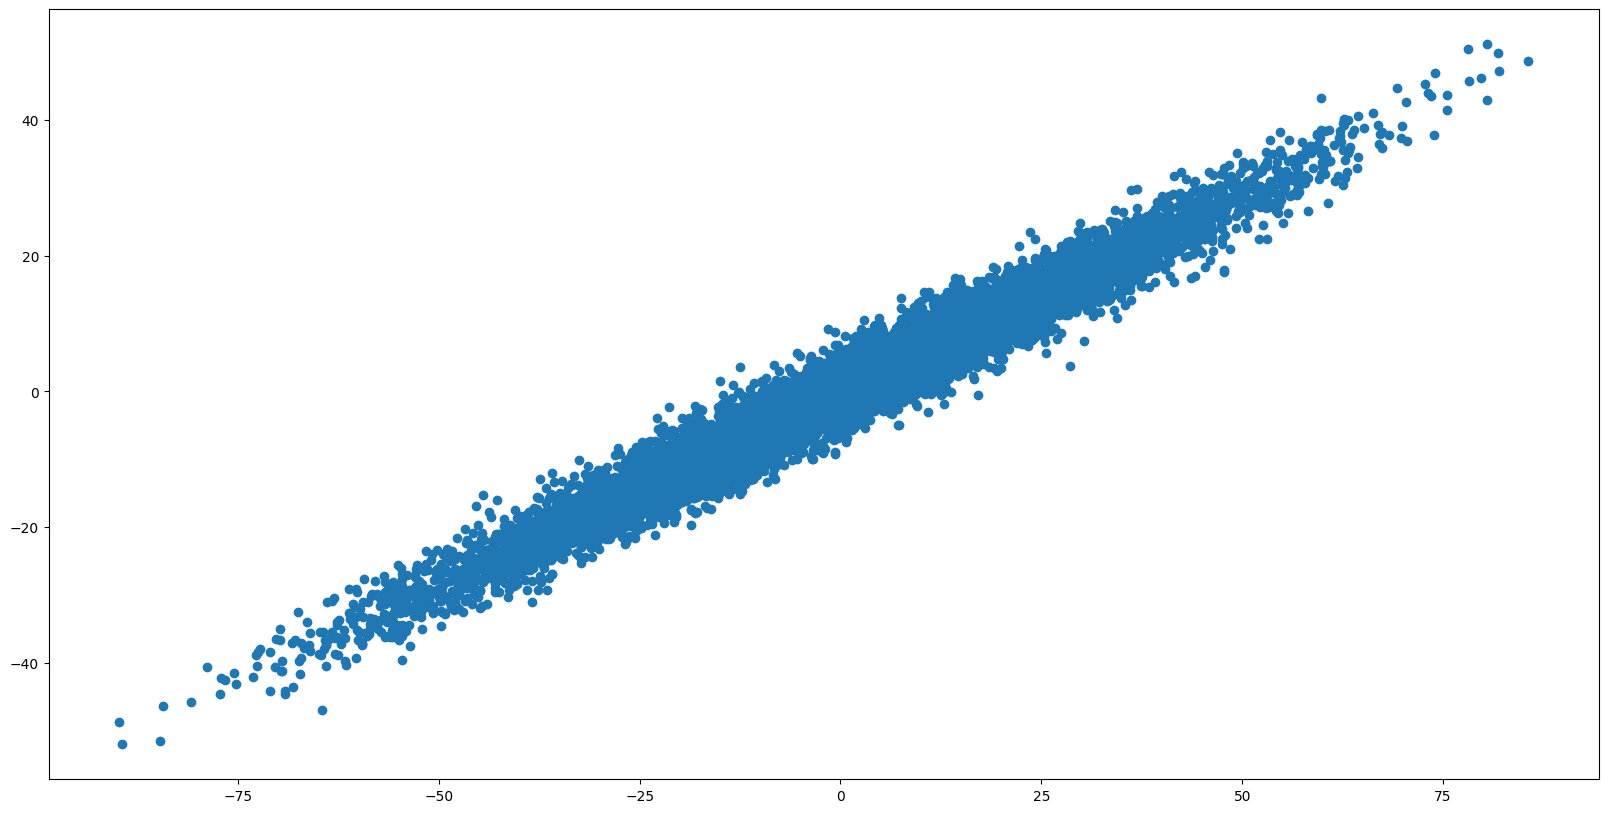

In [ ]:
plt.scatter(data[:,0], data[:,1])

In [ ]:
pca = PCA()
pca.fit(data/20)

In [ ]:
pca.s

array([427.47551355, 195.60854741,   0.52147109,   0.51641764,
         0.51505203,   0.51348819,   0.50856112,   0.50705345,
         0.50607902,   0.50320567,   0.5028298 ,   0.50078735,
         0.49897142,   0.49567755,   0.49482125,   0.49158843,
         0.48859882,   0.4870905 ,   0.48664001,   0.48159424])

In [ ]:
pca.explained_variance_ratio

array([0.67627403, 0.30945628, 0.00082498, 0.00081698, 0.00081482,
       0.00081235, 0.00080455, 0.00080217, 0.00080063, 0.00079608,
       0.00079549, 0.00079225, 0.00078938, 0.00078417, 0.00078282,
       0.0007777 , 0.00077297, 0.00077059, 0.00076987, 0.00076189])

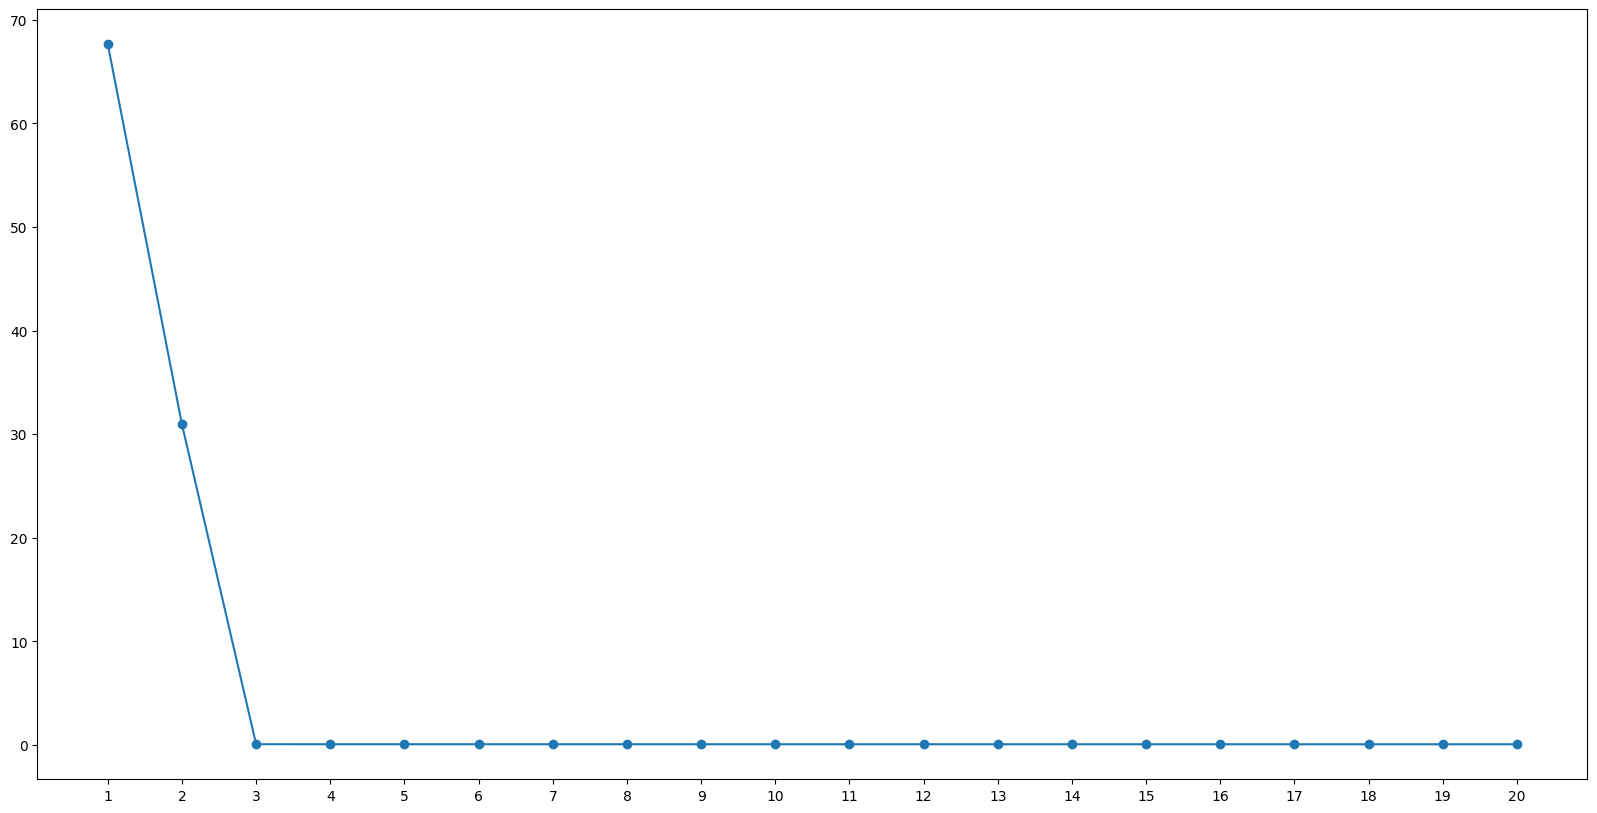

In [ ]:

plt.xticks(range(1, len(pca.s) + 1))
plt.plot(range(1, len(pca.s) + 1), # x-axis
         pca.explained_variance_ratio*100,
         marker='o',
        )


In [ ]:
X_2, v_2 = pca.predict(2)

In [ ]:
proj = numpy.matmul(X_2, v_2)

In [ ]:
data_centered  = data - numpy.mean(data, axis=0)

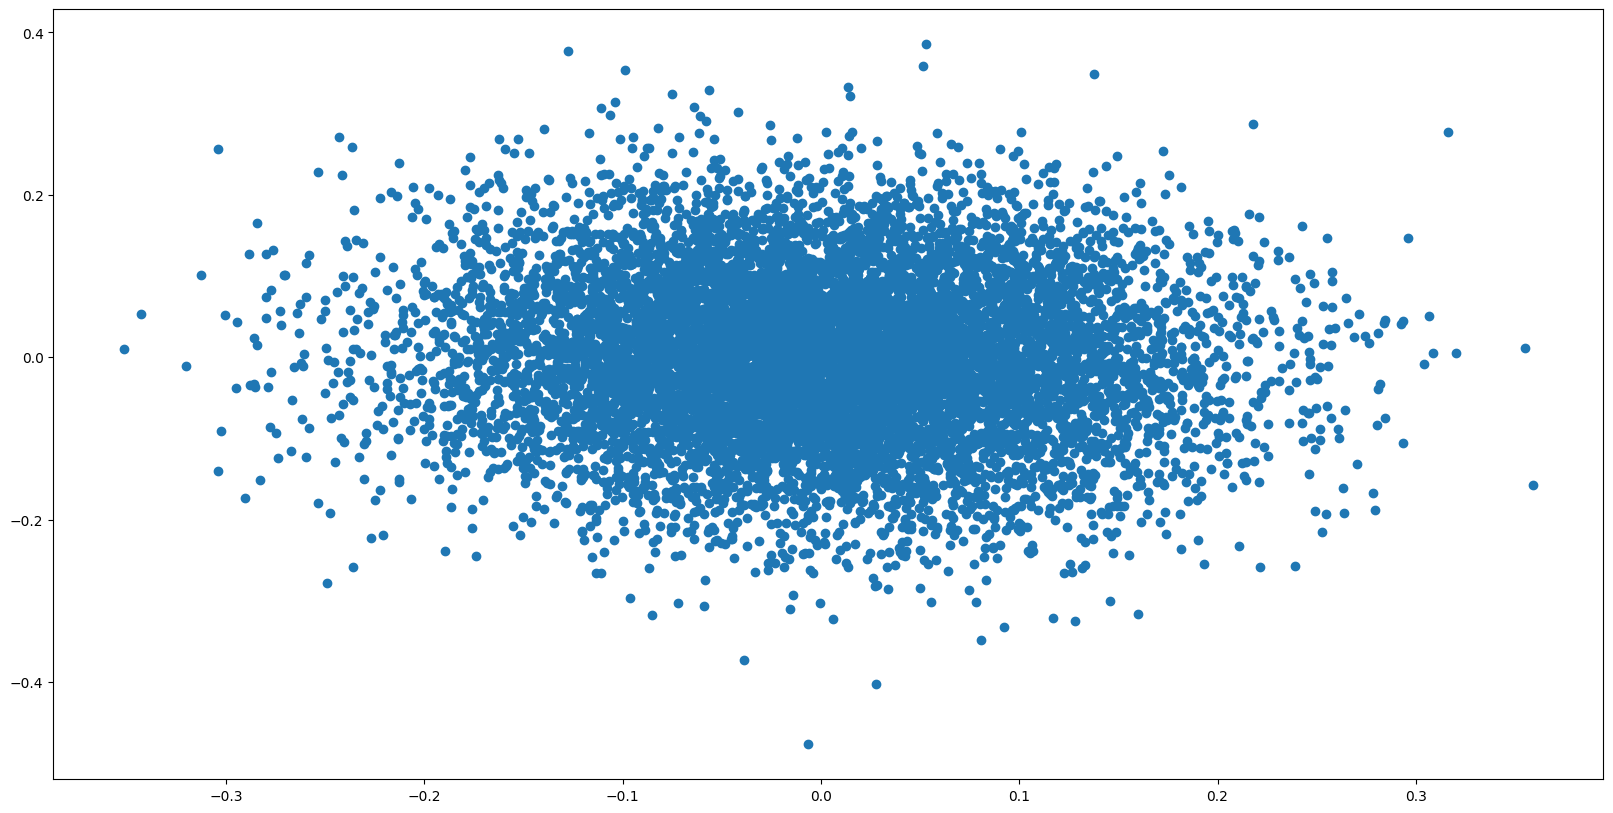

In [ ]:
plt.scatter((data_centered - proj)[:,0], (data_centered - proj)[:,1])

# Marchenko-Pastur

As $N \to \infty$, and $M/N \approx \lambda$, the singular values of a random matrix tend to

$$
  f(t) = \frac{1}{2 \pi \sigma^2} \frac{\sqrt{(\lambda_+ - t)(t - \lambda_- )}}{\lambda t}
  $$
  where $\lambda_\pm = \sigma^2 (1 \pm \sqrt{\lambda})^2$

In [ ]:
lbda = 10000/20

In [ ]:
sigma_2 = 0.1**2

In [ ]:
lbda_plus = sigma_2*(1 + numpy.sqrt(lbda))**2

In [ ]:
lbda_minus = sigma_2*(1 - numpy.sqrt(lbda))**2

In [ ]:
lbda_minus

np.float64(4.562786404500043)

In [ ]:
lbda_plus

np.float64(5.45721359549996)

In [ ]:
t = numpy.arange(lbda_minus, lbda_plus, 0.01)

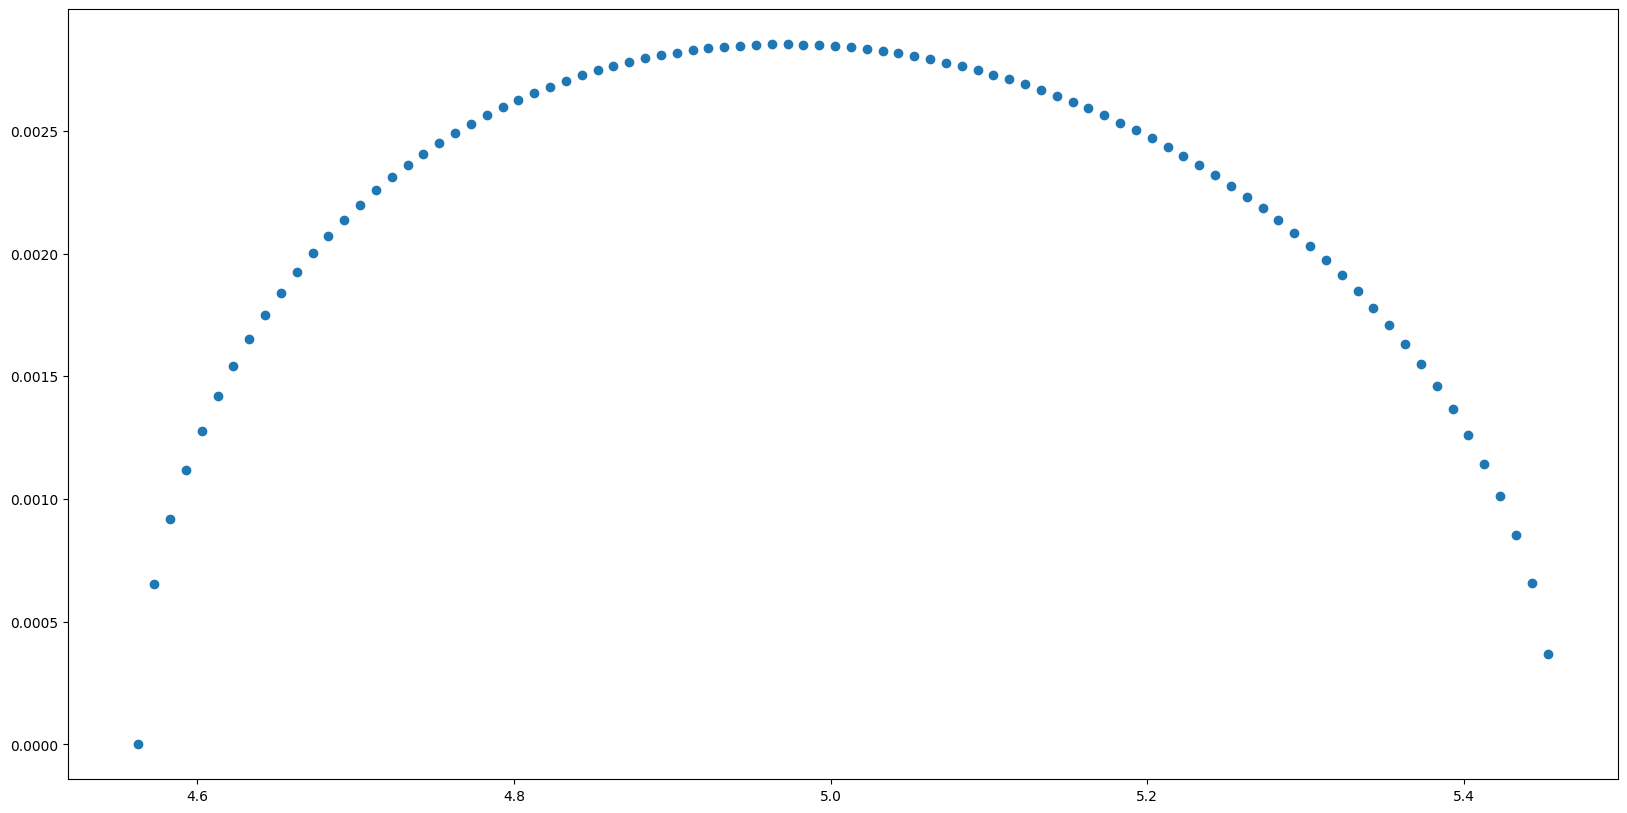

In [ ]:
#plt.plot(pca.s/20.)
plt.scatter(x = t, y = 1/(2*numpy.pi*sigma_2)*numpy.sqrt((lbda_plus - t)*(t - lbda_minus))/(lbda*t))

In [ ]:
t

array([4.5627864, 4.5727864, 4.5827864, 4.5927864, 4.6027864, 4.6127864,
       4.6227864, 4.6327864, 4.6427864, 4.6527864, 4.6627864, 4.6727864,
       4.6827864, 4.6927864, 4.7027864, 4.7127864, 4.7227864, 4.7327864,
       4.7427864, 4.7527864, 4.7627864, 4.7727864, 4.7827864, 4.7927864,
       4.8027864, 4.8127864, 4.8227864, 4.8327864, 4.8427864, 4.8527864,
       4.8627864, 4.8727864, 4.8827864, 4.8927864, 4.9027864, 4.9127864,
       4.9227864, 4.9327864, 4.9427864, 4.9527864, 4.9627864, 4.9727864,
       4.9827864, 4.9927864, 5.0027864, 5.0127864, 5.0227864, 5.0327864,
       5.0427864, 5.0527864, 5.0627864, 5.0727864, 5.0827864, 5.0927864,
       5.1027864, 5.1127864, 5.1227864, 5.1327864, 5.1427864, 5.1527864,
       5.1627864, 5.1727864, 5.1827864, 5.1927864, 5.2027864, 5.2127864,
       5.2227864, 5.2327864, 5.2427864, 5.2527864, 5.2627864, 5.2727864,
       5.2827864, 5.2927864, 5.3027864, 5.3127864, 5.3227864, 5.3327864,
       5.3427864, 5.3527864, 5.3627864, 5.3727864, 